# CareAssist - Placement Stability Prediction Model
**Train on real AFCARS FY2020-2024 data (5 years)**

## Instructions
1. Run Cell 1 to install packages
2. Run Cell 2 (imports)
3. Run Cell 3 - upload **Berkeley_AFCARS_CSVs_UTF8.zip**
4. Then **Runtime > Run all** remaining cells
5. Cell 16 will auto-download a zip with all outputs

In [5]:
# Cell 1: Install packages
# !pip install -q xgboost shap imbalanced-learn
# Adding CatBoost
!pip install -q xgboost shap imbalanced-learn catboost # Added

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.2 MB/s eta 0:00:00


In [6]:
# Cell 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os, glob, zipfile
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
#  Adding CatBoost
from catboost import CatBoostClassifier # Added

import xgboost as xgb
import shap
import joblib
from imblearn.over_sampling import SMOTE

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("All imports OK")

All imports OK


In [3]:
# Cell 3: Upload Berkeley_AFCARS_CSVs_UTF8.zip
from google.colab import files
print("Upload Berkeley_AFCARS_CSVs_UTF8.zip")
uploaded = files.upload()
print(f"Uploaded {len(uploaded)} file(s)")

# Extract the zip
import zipfile
for zf in uploaded.keys():
    if zf.endswith(".zip"):
        print(f"Extracting {zf}...")
        with zipfile.ZipFile(zf, "r") as z:
            z.extractall("afcars_csv")
            print(f"  Extracted {len(z.namelist())} files")
print("Done")

Upload Berkeley_AFCARS_CSVs_UTF8.zip


Saving Berkeley_AFCARS_CSVs_UTF8.zip to Berkeley_AFCARS_CSVs_UTF8 (1).zip
Uploaded 1 file(s)
Extracting Berkeley_AFCARS_CSVs_UTF8 (1).zip...
  Extracted 6 files
Done


In [4]:
# Cell 4: Load CSV files (excluding 2019)
csv_files = sorted(glob.glob("afcars_csv/**/*.csv", recursive=True) + glob.glob("afcars_csv/*.csv"))
# Also check if CSVs landed in a subfolder
if not csv_files:
    csv_files = sorted(glob.glob("**/*.csv", recursive=True))
csv_files = [f for f in csv_files if "2019" not in f]  # Exclude 2019
print(f"Found {len(csv_files)} CSV files (2019 excluded):")
for f in csv_files:
    print(f"  {f}")

USE_COLS = [
    "RecNumbr", "FIPSCode", "StFCID", "FY",
    "NUMPLEP", "TOTALREM", "CURPLSET", "CASEGOAL", "SEX", "CLINDIS",
    "MR", "VISHEAR", "PHYDIS", "EmotDist", "OTHERMED", "CHBEHPRB",
    "PHYABUSE", "SEXABUSE", "NEGLECT", "AAPARENT", "DAPARENT",
    "AACHILD", "DACHILD", "CHILDIS", "PRTSDIED", "PRTSJAIL",
    "NOCOPE", "ABANDMNT", "RELINQSH", "HOUSING", "MANREM",
    "EVERADPT", "DISREASN", "PLACEOUT",
    "AgeAtLatRem", "RaceEthn", "SettingLOS", "LatRemLOS",
]

def load_csv(path):
    header = pd.read_csv(path, nrows=0)
    cols = [c for c in USE_COLS if c in header.columns]
    d = pd.read_csv(path, usecols=cols, dtype=str, low_memory=False)
    for c in d.columns:
        if c not in ("RecNumbr", "FIPSCode", "StFCID", "FY"):
            d[c] = pd.to_numeric(d[c], errors="coerce")
    return d

dfs = []
for f in sorted(csv_files):
    print(f"Loading {os.path.basename(f)}...")
    d = load_csv(f)
    print(f"  {len(d):,} records")
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined: {len(df):,} records x {df.shape[1]} columns")
print(f'Fiscal years: {sorted(df["FY"].dropna().unique())}')
df.head()

Found 10 CSV files (2019 excluded):
  afcars_csv/FC2020ABv1.csv
  afcars_csv/FC2020ABv1.csv
  afcars_csv/FC2021ABv1.csv
  afcars_csv/FC2021ABv1.csv
  afcars_csv/FC2022ABv1.csv
  afcars_csv/FC2022ABv1.csv
  afcars_csv/FC2023ABv1.csv
  afcars_csv/FC2023ABv1.csv
  afcars_csv/FC2024ABv1.csv
  afcars_csv/FC2024ABv1.csv
Loading FC2020ABv1.csv...
  632,684 records
Loading FC2020ABv1.csv...
  632,684 records
Loading FC2021ABv1.csv...
  605,932 records
Loading FC2021ABv1.csv...
  605,932 records
Loading FC2022ABv1.csv...
  569,871 records
Loading FC2022ABv1.csv...
  569,871 records
Loading FC2023ABv1.csv...
  548,827 records
Loading FC2023ABv1.csv...
  548,827 records
Loading FC2024ABv1.csv...
  521,844 records
Loading FC2024ABv1.csv...
  521,844 records

Combined: 5,758,316 records x 38 columns
Fiscal years: ['2020', '2021', '2022', '2023', '2024']


,FY,FIPSCode,RecNumbr,SEX,CLINDIS,MR,VISHEAR,PHYDIS,EmotDist,OTHERMED,...,HOUSING,CURPLSET,PLACEOUT,CASEGOAL,DISREASN,LatRemLOS,SettingLOS,AgeAtLatRem,RaceEthn,StFCID
0,2020,00008,R99044225246,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2,2.0,1,99,70.0,70.0,0,3,NCR99044225246
1,2020,00008,R99044231032,1.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,8,2.0,6,99,415.0,81.0,0,1,NCR99044231032
2,2020,37051,R99044231063,1.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3,2.0,1,99,421.0,91.0,0,99,NCR99044231063
3,2020,00008,R99044232374,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3,2.0,2,99,318.0,318.0,6,1,NCR99044232374
4,2020,00008,R99044238028,1.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3,2.0,2,99,427.0,426.0,0,1,NCR99044238028


In [7]:
# Cell 5: Define target variable
# Disrupted = discharge reason Transfer(6)/Runaway(7) OR 3+ placements
# NUMPLEP excluded from features to avoid data leakage

DISRUPTION_CODES = {6, 7}

def label_disruption(row):
    d = row["DISREASN"]
    n = row["NUMPLEP"]
    if pd.notna(d) and int(d) in DISRUPTION_CODES:
        return 1
    if pd.notna(n) and int(n) >= 3:
        return 1
    return 0

df["disruption"] = df.apply(label_disruption, axis=1)
pos = df["disruption"].sum()
print(f"Disrupted: {pos:,} ({100*pos/len(df):.1f}%)")
print(f"Stable:    {len(df)-pos:,} ({100*(len(df)-pos)/len(df):.1f}%)")
print("\nBy fiscal year:")
print(df.groupby("FY")["disruption"].agg(["count","mean","sum"]).to_string())

Disrupted: 2,073,368 (36.0%)
Stable:    3,684,948 (64.0%)

By fiscal year:
        count      mean     sum
FY                             
2020  1265368  0.344643  436100
2021  1211864  0.344082  416980
2022  1139742  0.344541  392688
2023  1097654  0.385284  422908
2024  1043688  0.387752  404692


In [8]:
# Cell 6: Feature engineering
df["age_at_removal"] = df["AgeAtLatRem"].where(df["AgeAtLatRem"] < 99)

disability_cols = ["MR", "VISHEAR", "PHYDIS", "EmotDist", "OTHERMED"]
for c in disability_cols:
    df[c] = df[c].fillna(0).clip(0, 1).astype(int)
df["has_disability"] = df[disability_cols].max(axis=1)
df["has_clinical_disability"] = (df["CLINDIS"] == 1).astype(int)
df["has_behavioral"] = df["CHBEHPRB"].fillna(0).clip(0, 1).astype(int)

removal_reason_cols = [
    "PHYABUSE","SEXABUSE","NEGLECT","AAPARENT","DAPARENT",
    "AACHILD","DACHILD","CHILDIS","PRTSDIED","PRTSJAIL",
    "NOCOPE","ABANDMNT","RELINQSH","HOUSING"
]
for c in removal_reason_cols:
    df[c] = df[c].fillna(0).clip(0, 1).astype(int)
df["num_removal_reasons"] = df[removal_reason_cols].sum(axis=1)

df["placement_type"] = df["CURPLSET"].where(df["CURPLSET"].isin([1,2,3,4,5,6,7,8]))
df["case_goal"] = df["CASEGOAL"].where(df["CASEGOAL"].isin([1,2,3,4,5,6,7]))
df["total_removals"] = df["TOTALREM"].where(df["TOTALREM"] < 98)

if "SettingLOS" in df.columns:
    df["los_current_setting"] = pd.to_numeric(df["SettingLOS"], errors="coerce")
else:
    df["los_current_setting"] = np.nan
if "LatRemLOS" in df.columns:
    df["los_latest_removal"] = pd.to_numeric(df["LatRemLOS"], errors="coerce")
else:
    df["los_latest_removal"] = np.nan

df["ever_adopted"] = df["EVERADPT"].fillna(0).clip(0, 1).astype(int)
df["mandatory_removal"] = df["MANREM"].fillna(0).clip(0, 1).astype(int)

FEATURE_COLS = [
    "age_at_removal",
    "total_removals","placement_type","case_goal",
    "has_disability","has_clinical_disability","has_behavioral",
    "num_removal_reasons",
    "PHYABUSE","SEXABUSE","NEGLECT","AAPARENT","DAPARENT",
    "NOCOPE","ABANDMNT","HOUSING",
    "los_current_setting","los_latest_removal",
    "ever_adopted","mandatory_removal",
]
print(f"{len(FEATURE_COLS)} features (race, gender, NUMPLEP excluded)")

20 features (race, gender, NUMPLEP excluded)


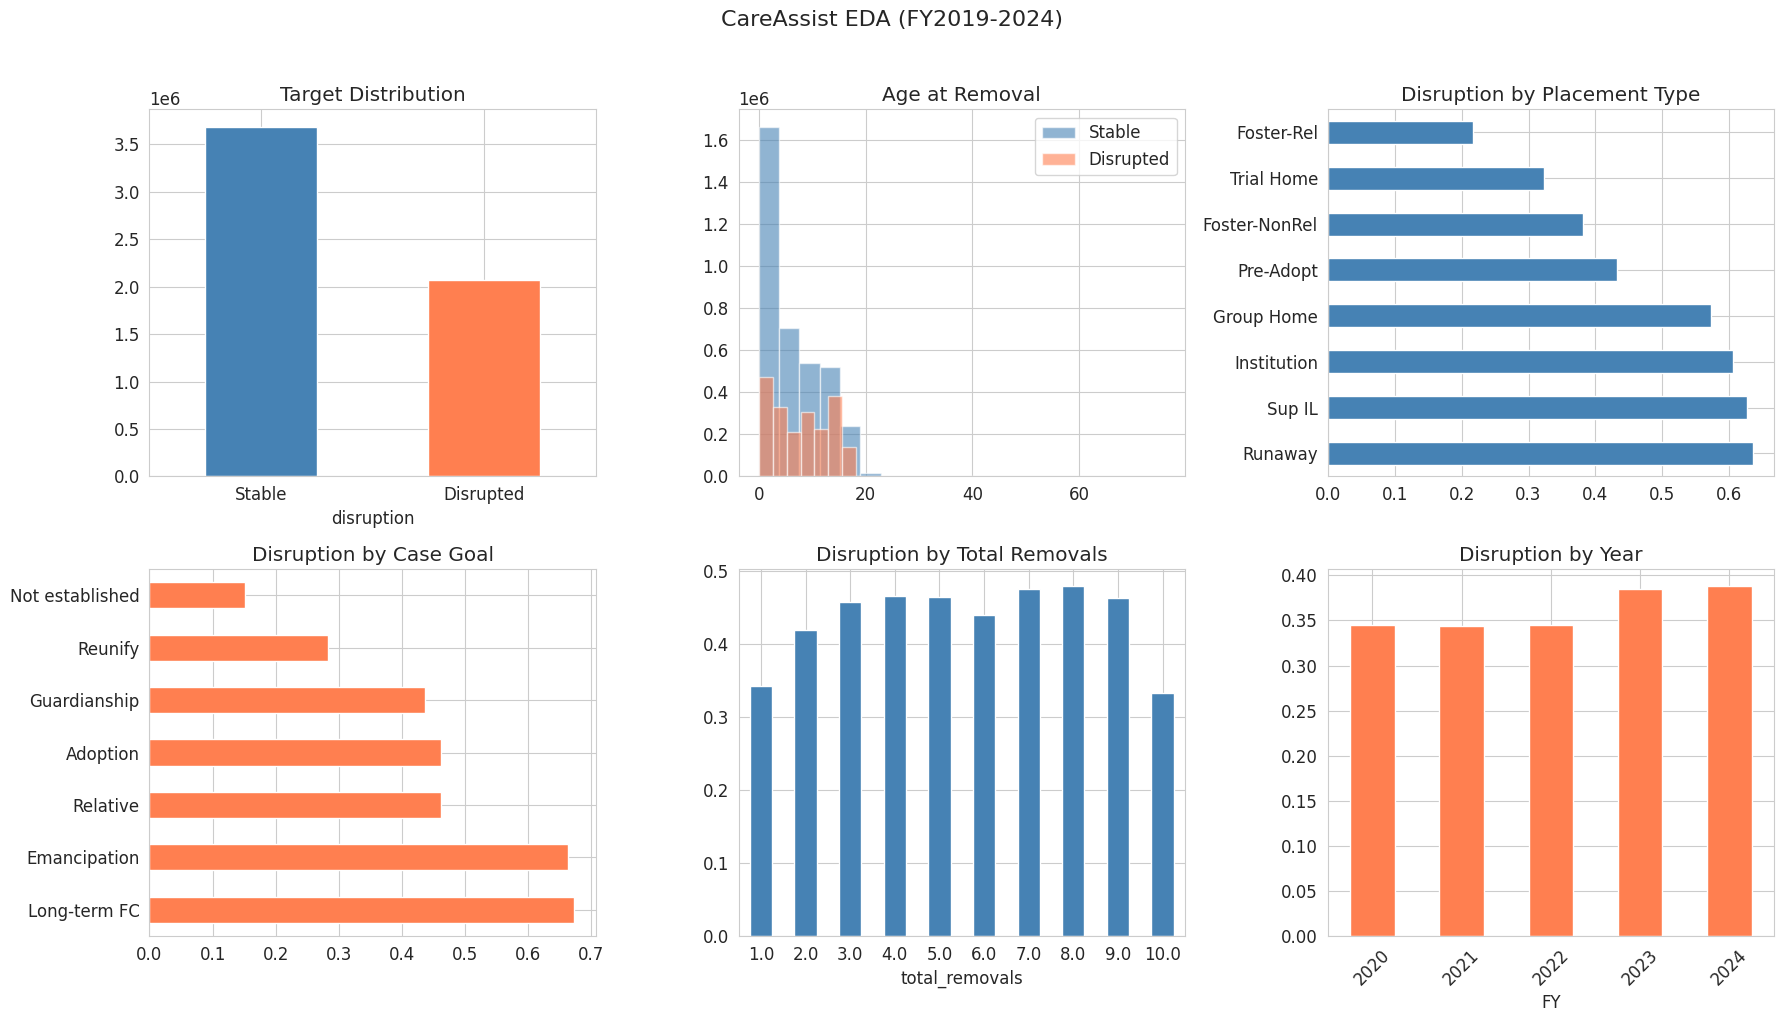

In [9]:
# Cell 7: EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df["disruption"].value_counts().plot(kind="bar", ax=axes[0,0], color=["steelblue","coral"])
axes[0,0].set_title("Target Distribution")
axes[0,0].set_xticklabels(["Stable","Disrupted"], rotation=0)

df[df["disruption"]==0]["age_at_removal"].hist(bins=20, ax=axes[0,1], alpha=0.6, label="Stable", color="steelblue")
df[df["disruption"]==1]["age_at_removal"].hist(bins=20, ax=axes[0,1], alpha=0.6, label="Disrupted", color="coral")
axes[0,1].set_title("Age at Removal"); axes[0,1].legend()

pt_labels = {1:"Pre-Adopt",2:"Foster-Rel",3:"Foster-NonRel",4:"Group Home",5:"Institution",6:"Sup IL",7:"Runaway",8:"Trial Home"}
pt_rates = df.groupby("placement_type")["disruption"].mean().sort_values(ascending=False)
pt_rates.index = [pt_labels.get(int(i),str(i)) for i in pt_rates.index]
pt_rates.plot(kind="barh", ax=axes[0,2], color="steelblue")
axes[0,2].set_title("Disruption by Placement Type")

cg_labels = {1:"Reunify",2:"Relative",3:"Adoption",4:"Long-term FC",5:"Emancipation",6:"Guardianship",7:"Not established"}
cg_rates = df.groupby("case_goal")["disruption"].mean().sort_values(ascending=False)
cg_rates.index = [cg_labels.get(int(i),str(i)) for i in cg_rates.index]
cg_rates.plot(kind="barh", ax=axes[1,0], color="coral")
axes[1,0].set_title("Disruption by Case Goal")

tr = df.groupby("total_removals")["disruption"].mean().head(10)
tr.plot(kind="bar", ax=axes[1,1], color="steelblue")
axes[1,1].set_title("Disruption by Total Removals")
axes[1,1].tick_params(axis="x", rotation=0)

yr = df.groupby("FY")["disruption"].mean()
yr.plot(kind="bar", ax=axes[1,2], color="coral")
axes[1,2].set_title("Disruption by Year")
axes[1,2].tick_params(axis="x", rotation=45)

plt.suptitle("CareAssist EDA (FY2019-2024)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Cell 8: Prepare data - changed to remove the one-hot encoding since CatBoost handles categoricals
model_df = df[FEATURE_COLS + ["disruption"]].copy()

# Fill NaNs in categorical columns with a placeholder for CatBoost
cat_features = ["placement_type", "case_goal"]
for c in cat_features:
    model_df[c] = model_df[c].fillna(-1).astype(int)

# Fill remaining NaNs with median
for c in model_df.columns:
    if model_df[c].isna().any():
        model_df[c] = model_df[c].fillna(model_df[c].median())

y = model_df["disruption"]
X = model_df.drop(columns=["disruption"])
feature_names = list(X.columns)

cat_feature_indices = [feature_names.index(c) for c in cat_features if c in feature_names]
print(f"Categorical feature indices: {cat_feature_indices} -> {cat_features}")

print(f"Features: {len(feature_names)}, Records: {len(X):,}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Disruption rate: train={y_train.mean():.3f} test={y_test.mean():.3f}")
print("Skipping SMOTE — 36% positive rate is balanced enough")

Categorical feature indices: [2, 3] -> ['placement_type', 'case_goal']
Features: 20, Records: 5,758,316
Train: 4,606,652  Test: 1,151,664
Disruption rate: train=0.360 test=0.360
Skipping SMOTE — 36% positive rate is balanced enough


In [ ]:
# Cell 8.2: Prepare data (modified)
model_df = df[FEATURE_COLS + ["disruption"]].copy()

# One-hot encode categorical columns (used by both XGBoost and CatBoost)
cat_cols = ["placement_type", "case_goal"]
model_df = pd.get_dummies(model_df, columns=cat_cols, prefix=cat_cols, dummy_na=False)

# Fill remaining NaNs with median
for c in model_df.columns:
    if model_df[c].isna().any():
        model_df[c] = model_df[c].fillna(model_df[c].median())

y = model_df["disruption"]
X = model_df.drop(columns=["disruption"])
feature_names = list(X.columns)

# No categorical features for CatBoost since everything is now numeric
cat_feature_indices = []
print(f"Categorical feature indices: {cat_feature_indices} (using one-hot encoding instead)")

print(f"Features: {len(feature_names)}, Records: {len(X):,}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Disruption rate: train={y_train.mean():.3f} test={y_test.mean():.3f}")
print("Skipping SMOTE — 36% positive rate is balanced enough")

In [12]:
# Cell 9: Random Forest
# print("Training Random Forest...")
# rf = RandomForestClassifier(
#     n_estimators=500, max_depth=16, min_samples_leaf=50,
#     class_weight="balanced", random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train)
# rf_proba = rf.predict_proba(X_test)[:,1]
# rf_auc = roc_auc_score(y_test, rf_proba)
# rf_ap = average_precision_score(y_test, rf_proba)
# print(f"  ROC-AUC: {rf_auc:.4f}  Avg Precision: {rf_ap:.4f}")

In [13]:
# Cell 10: XGBoost + CatBoost
# print("Training XGBoost...")
# neg, pos_count = (y_train==0).sum(), (y_train==1).sum()
# scale_pos = neg / max(pos_count, 1)
# xgb_model = xgb.XGBClassifier(
#     n_estimators=500, max_depth=8, learning_rate=0.05,
#     subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
#     tree_method="hist", eval_metric="logloss",
#     random_state=42, n_jobs=-1)
# xgb_model.fit(X_train, y_train, verbose=False)
# xgb_proba = xgb_model.predict_proba(X_test)[:,1]
# xgb_auc = roc_auc_score(y_test, xgb_proba)
# xgb_ap = average_precision_score(y_test, xgb_proba)
# print(f"  ROC-AUC: {xgb_auc:.4f}  Avg Precision: {xgb_ap:.4f}")

print("Training CatBoost...")
# Same parameters as XGBoost - just a different model
cat_model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    eval_metric="AUC",
    auto_class_weights="Balanced",
    cat_features=cat_feature_indices,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)
cat_proba = cat_model.predict_proba(X_test)[:, 1]
cat_auc = roc_auc_score(y_test, cat_proba)
cat_ap = average_precision_score(y_test, cat_proba)
print(f"  ROC-AUC: {cat_auc:.4f}  Avg Precision: {cat_ap:.4f}")

# results = {
#     "RandomForest": (rf, rf_proba, rf_auc),
#     "XGBoost": (xgb_model, xgb_proba, xgb_auc),
#     "CatBoost": (cat_model, cat_proba, cat_auc),
# }
# best_name = max(results, key=lambda k: results[k][2])
# best_model, best_proba, best_auc = results[best_name]
# print(f"\nBest: {best_name} (AUC={best_auc:.4f})")

Training CatBoost...
  ROC-AUC: 0.8990  Avg Precision: 0.8280


In [ ]:
# Cell 10.5 - Training CatBoost with modified parameters
print("Training CatBoost with modified parameters...")
cat_model_2 = CatBoostClassifier(
    iterations=1000,
    depth=10,
    learning_rate=0.05,
    eval_metric="AUC",
    auto_class_weights="Balanced",
    cat_features=cat_feature_indices,
    l2_leaf_reg=5,
    bagging_temperature=0.5,
    min_data_in_leaf=50,
    random_seed=42,
    verbose=0
)
cat_model_2.fit(X_train, y_train)

              precision    recall  f1-score   support

      Stable       0.92      0.73      0.81    736990
   Disrupted       0.65      0.89      0.75    414674

    accuracy                           0.79   1151664
   macro avg       0.79      0.81      0.78   1151664
weighted avg       0.83      0.79      0.79   1151664



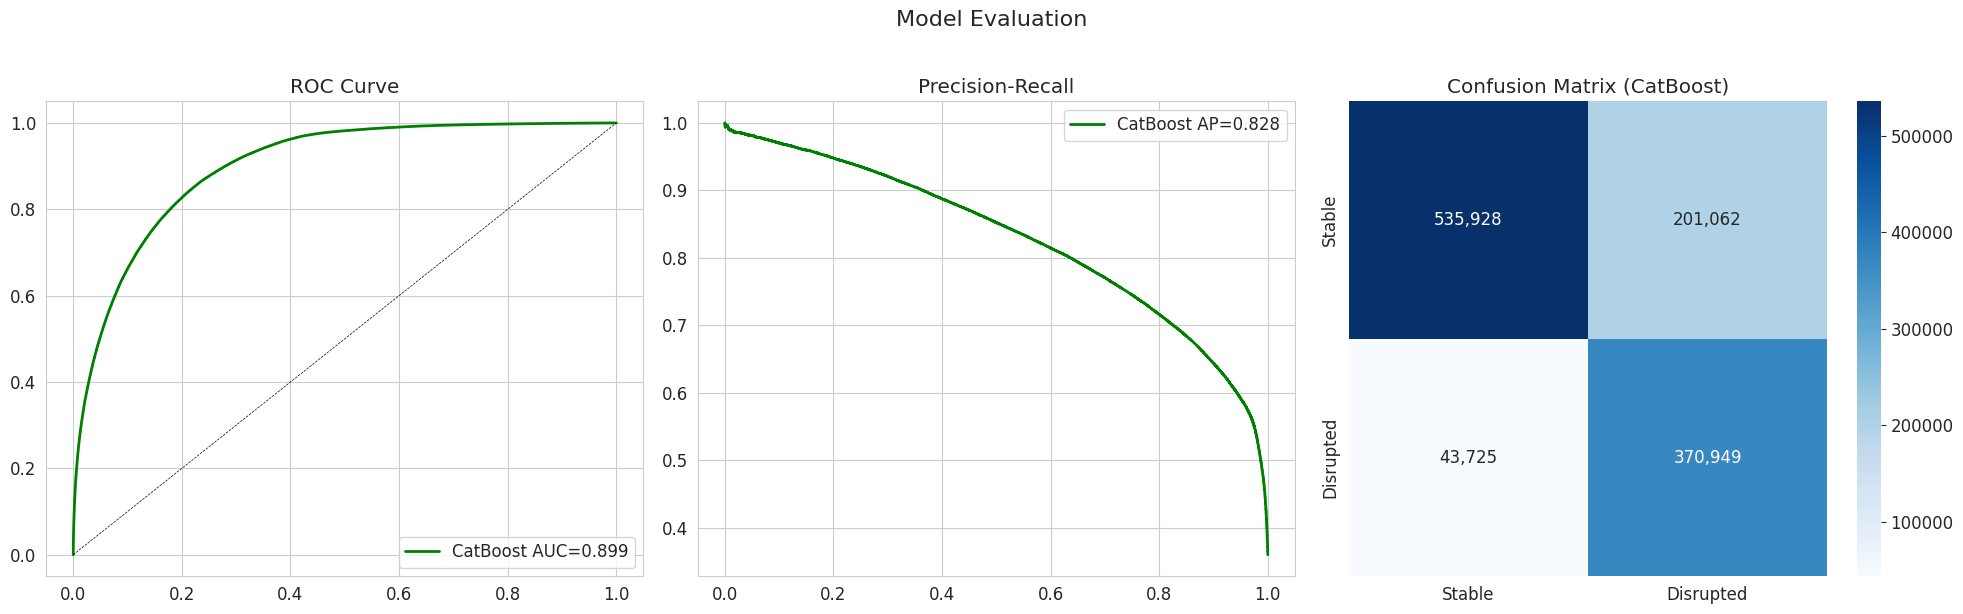

In [18]:
# Cell 11: Evaluation plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
# fpr_xg, tpr_xg, _ = roc_curve(y_test, xgb_proba)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_proba)
# axes[0].plot(fpr_rf, tpr_rf, "b-", lw=2, label=f"RF AUC={rf_auc:.3f}")
# axes[0].plot(fpr_xg, tpr_xg, "r-", lw=2, label=f"XGB AUC={xgb_auc:.3f}")
axes[0].plot(fpr_cat, tpr_cat, "g-", lw=2, label=f"CatBoost AUC={cat_auc:.3f}")
axes[0].plot([0,1],[0,1],"k--",lw=0.5)
axes[0].set_title("ROC Curve"); axes[0].legend()

# p_rf, r_rf, _ = precision_recall_curve(y_test, rf_proba)
# p_xg, r_xg, _ = precision_recall_curve(y_test, xgb_proba)
p_cat, r_cat, _ = precision_recall_curve(y_test, cat_proba)
# axes[1].plot(r_rf, p_rf, "b-", lw=2, label=f"RF AP={rf_ap:.3f}")
# axes[1].plot(r_xg, p_xg, "r-", lw=2, label=f"XGB AP={xgb_ap:.3f}")
axes[1].plot(r_cat, p_cat, "g-", lw=2, label=f"CatBoost AP={cat_ap:.3f}")
axes[1].set_title("Precision-Recall"); axes[1].legend()

# y_pred = (best_proba >= 0.4).astype(int)


y_pred = (cat_proba >= 0.4).astype(int)
print(classification_report(y_test, y_pred, target_names=["Stable","Disrupted"]))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
    xticklabels=["Stable","Disrupted"], yticklabels=["Stable","Disrupted"], ax=axes[2])
axes[2].set_title("Confusion Matrix (CatBoost)")

plt.suptitle("Model Evaluation", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

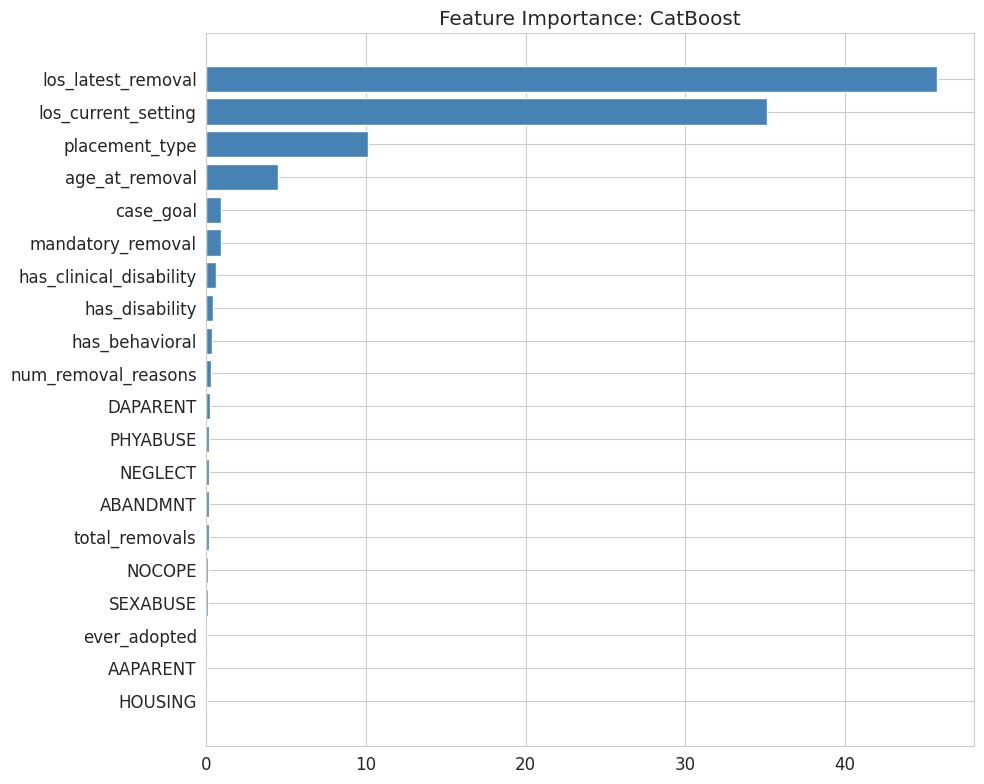

                feature  importance
     los_latest_removal   45.794812
    los_current_setting   35.092265
         placement_type   10.120839
         age_at_removal    4.510527
              case_goal    0.891531
      mandatory_removal    0.891433
has_clinical_disability    0.616263
         has_disability    0.399445
         has_behavioral    0.328822
    num_removal_reasons    0.257288
               DAPARENT    0.227887
               PHYABUSE    0.184572
                NEGLECT    0.184043
               ABANDMNT    0.136235
         total_removals    0.128883
                 NOCOPE    0.086605
               SEXABUSE    0.068387
           ever_adopted    0.056094
               AAPARENT    0.015013
                HOUSING    0.009055


In [19]:
# Cell 12: Feature importance
feat_imp = pd.DataFrame({"feature":feature_names, "importance":cat_model.feature_importances_}
    ).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_imp.head(20)
ax.barh(range(len(top20)), top20["importance"].values, color="steelblue")
ax.set_yticks(range(len(top20))); ax.set_yticklabels(top20["feature"].values)
ax.invert_yaxis(); ax.set_title(f"Feature Importance: CatBoost")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(feat_imp.head(20).to_string(index=False))

Computing SHAP (sample=1000)...


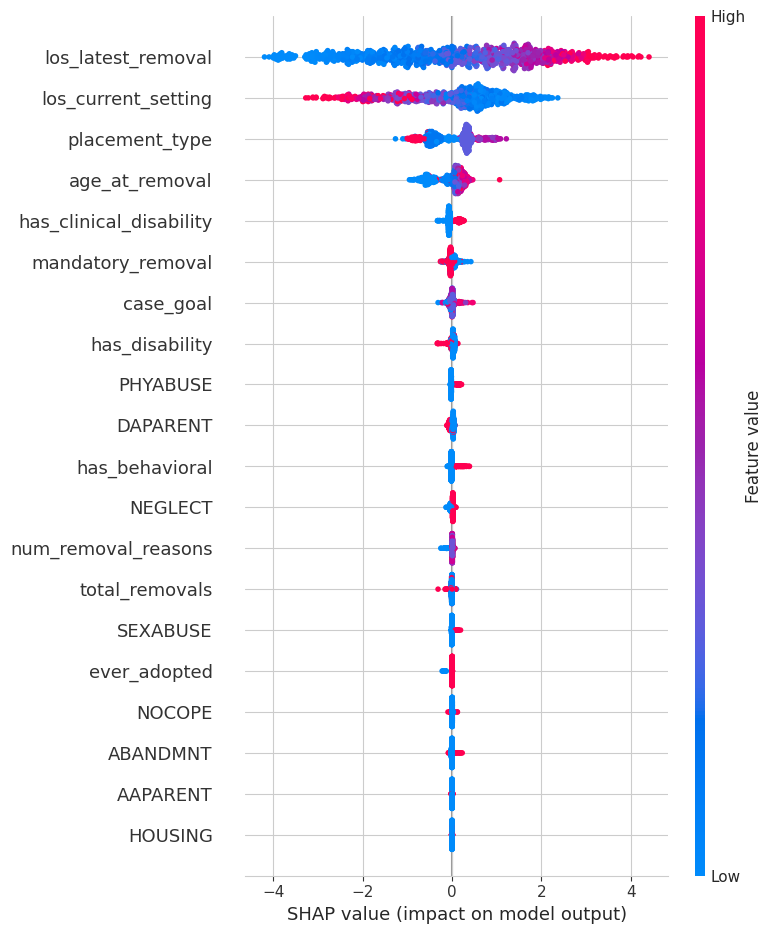

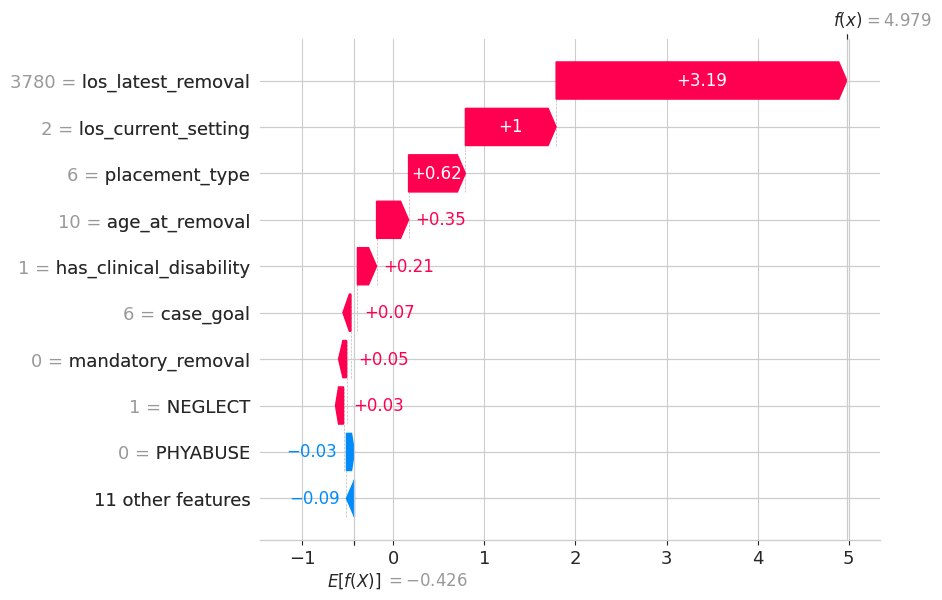

SHAP done


In [20]:
# Cell 13: SHAP
print("Computing SHAP (sample=1000)...")
explainer = shap.TreeExplainer(cat_model)
X_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)
if isinstance(shap_values, list): shap_values = shap_values[1]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False, max_display=20)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

idx = np.argmax(cat_model.predict_proba(X_sample)[:,1])
ev = explainer.expected_value
if isinstance(ev, list): ev = ev[1]
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx], base_values=ev,
    data=X_sample.iloc[idx], feature_names=feature_names), show=True)
print("SHAP done")

Scoring all records...
Risk Tier Distribution:
    Critical: 1,262,972 (21.9%)
        High:  897,252 (15.6%)
      Medium: 1,008,520 (17.5%)
         Low: 2,589,572 (45.0%)


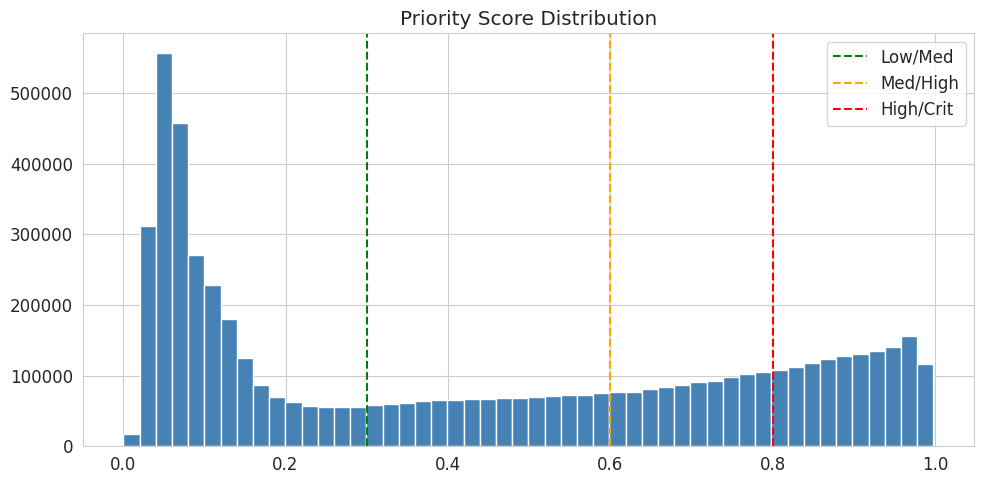

In [21]:
# Cell 14: Score all records
print("Scoring all records...")
X_all = model_df.drop(columns=["disruption"])
df["priority_score"] = cat_model.predict_proba(X_all)[:,1]
df["risk_tier"] = pd.cut(df["priority_score"],
    bins=[0,0.3,0.6,0.8,1.0], labels=["Low","Medium","High","Critical"], include_lowest=True)

print("Risk Tier Distribution:")
tier_dist = df["risk_tier"].value_counts()
for t in ["Critical","High","Medium","Low"]:
    if t in tier_dist.index:
        print(f"  {t:>10}: {tier_dist[t]:>8,} ({100*tier_dist[t]/len(df):.1f}%)")

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df["priority_score"], bins=50, color="steelblue", edgecolor="white")
for v,c,l in [(0.3,"green","Low/Med"),(0.6,"orange","Med/High"),(0.8,"red","High/Crit")]:
    ax.axvline(v, color=c, ls="--", label=l)
ax.set_title("Priority Score Distribution"); ax.legend()
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Cell 15: Export everything
os.makedirs("careassist_model_output", exist_ok=True)

joblib.dump(cat_model, "careassist_model_output/placement_model.pkl")
print("placement_model.pkl")

# Save CatBoost model too
cat_model.save_model("careassist_model_output/catboost_model.cbm")
print("catboost_model.cbm")

meta = {
    "model_type": "CatBoost",
    "roc_auc": round(cat_auc, 4),
    "threshold": 0.4,

    "feature_names": feature_names,
    "feature_count": len(feature_names),
    "cat_feature_indices": cat_feature_indices,

    "train_samples": int(len(X_train)),
    "test_samples": int(len(X_test)),
    "total_records": int(len(df)),
    "disruption_rate": round(float(y.mean()), 4),
    "years": sorted([str(x) for x in df["FY"].dropna().unique()]),

    "risk_tiers": {
        "Low": "0-0.3",
        "Medium": "0.3-0.6",
        "High": "0.6-0.8",
        "Critical": "0.8-1.0"
    },
}
with open("careassist_model_output/model_metadata.json","w") as f:
    json.dump(meta, f, indent=2)
print("model_metadata.json")

feat_imp.to_csv("careassist_model_output/feature_importance.csv", index=False)
print("feature_importance.csv")

export_cols = ["RecNumbr","StFCID","FIPSCode","FY",
    "age_at_removal","total_removals","placement_type","case_goal",
    "has_disability","has_clinical_disability","has_behavioral","num_removal_reasons",
    "los_current_setting","los_latest_removal","disruption","priority_score","risk_tier"]
export_cols = [c for c in export_cols if c in df.columns]
df[export_cols].to_csv("careassist_model_output/scored_cases.csv", index=False)
print(f"scored_cases.csv ({len(df):,} records)")

import shutil
for fn in ["eda_plots.png","model_evaluation.png","feature_importance.png","shap_summary.png","score_distribution.png"]:
    if os.path.exists(fn): shutil.copy(fn, f"careassist_model_output/{fn}")
all_files = os.listdir("careassist_model_output")
print(f"\nAll files: {all_files}")

placement_model.pkl
catboost_model.cbm
model_metadata.json
feature_importance.csv
scored_cases.csv (5,758,316 records)

All files: ['eda_plots.png', 'scored_cases.csv', 'score_distribution.png', 'model_metadata.json', 'feature_importance.png', 'placement_model.pkl', 'shap_summary.png', 'catboost_model.cbm', 'feature_importance.csv', 'model_evaluation.png']


In [23]:
# Cell 16: Download zip
import shutil
shutil.make_archive("careassist_model_output", "zip", ".", "careassist_model_output")
print("Downloading careassist_model_output.zip...")
files.download("careassist_model_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 17: Model Output
print("="*60)
print("Model Output")
print("="*60)
print(f"MODEL_TYPE=CatBoost)
print(f"ROC_AUC={cat_auc:.4f}")
print(f"RF_AUC={rf_auc:.4f}")
# print(f"XGB_AUC={xgb_auc:.4f}")
print(f"CAT_AUC={cat_auc:.4f}") # ADDED
print(f"TOTAL_RECORDS={len(df):,}")
print(f"DISRUPTION_RATE={y.mean():.4f}")
print(f"FEATURES={len(feature_names)}")
print(f"TRAIN_SAMPLES={len(X_train):,}")
print(f"TEST_SAMPLES={len(X_test):,}")
print(f'YEARS={sorted(df["FY"].dropna().unique().tolist())}')
print(f"\nTIER_DISTRIBUTION:")
for t in ["Critical","High","Medium","Low"]:
    if t in tier_dist.index: print(f"  {t}: {tier_dist[t]:,}")
print(f"\nTOP_10_FEATURES:")
for _,r in feat_imp.head(10).iterrows():
    print(f'  {r["feature"]}: {r["importance"]:.4f}')
print(f"\nCLASSIFICATION_REPORT:")
print(classification_report(y_test, y_pred, target_names=["Stable","Disrupted"]))
cm = confusion_matrix(y_test, y_pred)
print(f"CONFUSION_MATRIX: TN={cm[0,0]:,} FP={cm[0,1]:,} FN={cm[1,0]:,} TP={cm[1,1]:,}")
print("="*60)

Model Output
MODEL_TYPE=XGBoost
ROC_AUC=0.9057
RF_AUC=0.8832
XGB_AUC=0.9057
TOTAL_RECORDS=5,758,316
DISRUPTION_RATE=0.3601
FEATURES=33
TRAIN_SAMPLES=4,606,652
TEST_SAMPLES=1,151,664
YEARS=['2020', '2021', '2022', '2023', '2024']

TIER_DISTRIBUTION:
  Critical: 1,268,966
  High: 928,210
  Medium: 1,064,494
  Low: 2,496,646

TOP_10_FEATURES:
  los_latest_removal: 0.1551
  los_current_setting: 0.1413
  placement_type_2.0: 0.1283
  placement_type_8.0: 0.1151
  placement_type_1.0: 0.0440
  placement_type_3.0: 0.0374
  placement_type_5.0: 0.0337
  age_at_removal: 0.0309
  case_goal_3.0: 0.0305
  has_disability: 0.0277

CLASSIFICATION_REPORT:
              precision    recall  f1-score   support

      Stable       0.94      0.72      0.81    736990
   Disrupted       0.64      0.91      0.76    414674

    accuracy                           0.79   1151664
   macro avg       0.79      0.81      0.78   1151664
weighted avg       0.83      0.79      0.79   1151664

CONFUSION_MATRIX: TN=528,473 